In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
data_dir = Path("../data")

In [3]:
import tszip
ts_file = data_dir / "sc2ts_viridian_v2.2.trees.tsz"
ts = tszip.decompress(ts_file)

In [4]:
# Sampling date and location are not stored in node metadata.
sample_ids = []
for node in ts.nodes():
    if node.is_sample():
        sample_id = node.metadata.get("sample_id")
        assert sample_id != None
        sample_ids.append(sample_id)
print(len(sample_ids))

3114609


In [5]:
md_file = data_dir / "run_metadata.v05.tsv.gz"
md_df = pd.read_csv(md_file, sep="\t")
md_df.columns

/var/folders/4h/9ylb643n37d8jc7srjm7qzk00000gr/T/ipykernel_48701/1465852608.py:2: DtypeWarning: Columns (18,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  md_df = pd.read_csv(md_file, sep="\t")


Index(['In_may_2024_preprint', 'Study', 'Sample', 'Experiment', 'Run',
       'Run_count', 'Platform', 'Country', 'Region', 'Collection_date',
       'First_created', 'Date_tree', 'Date_tree_order', 'Viridian_result',
       'Genbank_accession', 'Genbank_other_runs', 'In_Viridian_tree',
       'In_intersection', 'Artic_primer_version', 'Viridian_amplicon_scheme',
       'Viridian_N', 'Genbank_N', 'Viridian_pangolin', 'Viridian_scorpio',
       'Genbank_pangolin', 'Genbank_scorpio', 'Genbank_tree_name',
       'Viridian_cons_len', 'Viridian_cons_het', 'Viridian_pangolin_1.29',
       'Viridian_scorpio_1.29'],
      dtype='object')

In [6]:
sub_df = md_df[md_df.Run.isin(sample_ids)][["Run", "Date_tree", "Country"]].reset_index(drop=True)
sub_df

,Run,Date_tree,Country
0,ERR6546375,2021-08-02,Estonia
1,ERR6546376,2021-08-02,Estonia
2,ERR6546380,2021-08-02,Estonia
3,ERR6546381,2021-08-02,Estonia
4,ERR6546382,2021-08-02,Estonia
...,...,...,...
3114604,ERR13177478,2023-04-20,Argentina
3114605,ERR13177479,2023-04-21,Argentina
3114606,ERR13177480,2023-04-24,Argentina
3114607,ERR13177481,2023-04-26,Argentina


In [7]:
assert all(sub_df["Country"].notna())
assert all(sub_df["Country"] != "")

In [8]:
sub_df["Country"].unique()

array(['Estonia', 'Pakistan', 'Chile', 'United Kingdom', 'Canada', 'USA',
       'Bangladesh', 'India', 'Thailand', 'Australia', 'Timor-Leste',
       'Japan', 'Uganda', 'Slovakia', 'Zimbabwe', 'South Africa',
       'Germany', 'Romania', 'Brazil', 'Finland', 'Kenya', 'Iraq',
       'Mozambique', 'Latvia', 'Mexico', 'Italy', 'Belgium',
       'Switzerland', 'Philippines', 'Cameroon', 'Croatia', 'France',
       'Spain', 'Malaysia', 'Hungary', 'Malta', 'Botswana', 'Qatar',
       'Lebanon', 'Israel', 'Ghana', 'Namibia', 'Russia', 'Malawi',
       'Ethiopia', 'New Zealand', 'Norway', 'Kuwait', 'Jordan', 'Uruguay',
       'Mauritius', 'Austria', 'Portugal', 'Hong Kong', 'UNKNOWN',
       'Northern Mariana Islands', 'Seychelles', 'China', 'Morocco',
       'Rwanda', 'Angola', 'Netherlands', 'Denmark', 'Viet Nam',
       'South Korea', 'Singapore', 'Saudi Arabia', 'Curacao', 'Sri Lanka',
       'Bhutan', 'Argentina'], dtype=object)

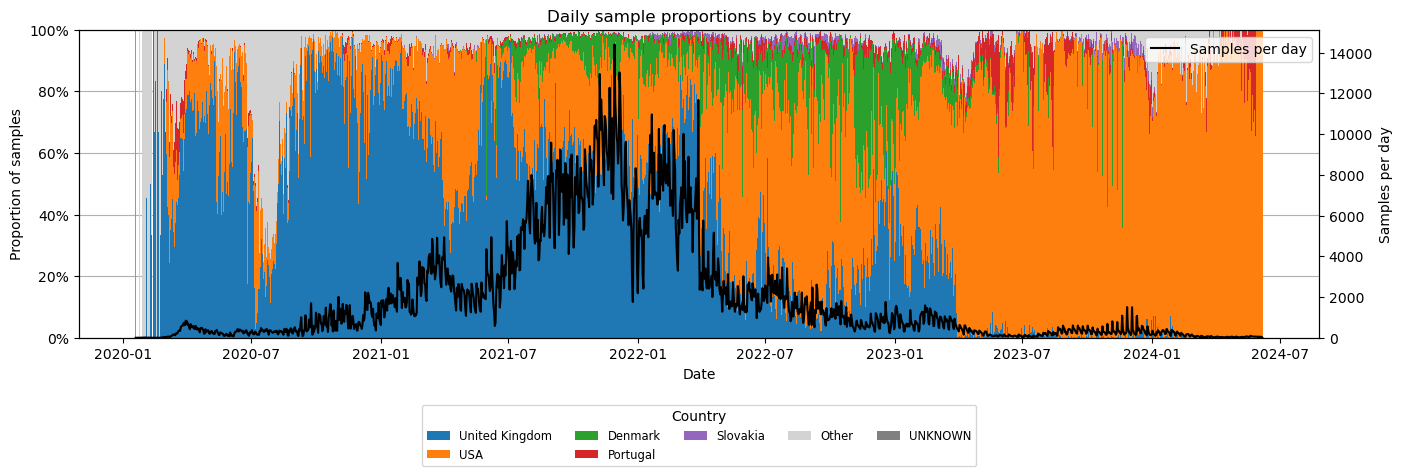

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

UNKNOWN = "UNKNOWN"

geo_df = sub_df.copy()
geo_df["Date_tree"] = pd.to_datetime(geo_df["Date_tree"], errors="raise")
# Rank known countries by total samples across all dates.
top_countries = geo_df.loc[geo_df["Country"] != UNKNOWN, "Country"].value_counts().head(5).index
geo_df["Country_group"] = geo_df["Country"].where(
    geo_df["Country"].isin(top_countries) | geo_df["Country"].eq(UNKNOWN), "Other"
)
country_order = list(top_countries) + ["Other", UNKNOWN]
daily_counts = pd.crosstab(geo_df["Date_tree"], geo_df["Country_group"]).sort_index()
daily_counts = daily_counts.reindex(columns=country_order, fill_value=0)
daily_proportions = daily_counts.div(daily_counts.sum(axis=1), axis=0)
country_colors = {country: plt.get_cmap("tab10")(i) for i, country in enumerate(top_countries)}
country_colors.update({"Other": "lightgrey", UNKNOWN: "grey"})

fig, ax = plt.subplots(figsize=(16, 4))
bottom = np.zeros(len(daily_proportions), dtype=np.float64)
for country in daily_proportions:
    proportions = daily_proportions[country].to_numpy()
    ax.bar(daily_proportions.index, proportions, bottom=bottom,
           width=1.0, label=country, color=country_colors[country], linewidth=0)
    bottom += proportions

ax.set_xlabel("Date")
ax.set_ylabel("Proportion of samples")
ax.set_title("Daily sample proportions by country")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_axisbelow(True)
ax.grid(axis="y")
ax.legend(title="Country", loc="upper center", bbox_to_anchor=(0.5, -0.2),
          ncol=5, fontsize="small")
ax_count = ax.twinx()
daily_totals = daily_counts.sum(axis=1)
ax_count.plot(daily_totals.index, daily_totals, color="black",
              label="Samples per day")
ax_count.set_ylabel("Samples per day")
ax_count.set_ylim(bottom=0)
ax_count.legend(loc="upper right")

# Save the date axis for the parent-time figure.
daily_sample_xlim = ax.get_xlim()
daily_sample_xticks = ax.get_xticks()
daily_sample_xticklabels = [label.get_text() for label in ax.get_xticklabels()]

plt.show()

In [10]:
recomb_file = data_dir / "recombinants.csv"
recomb_df = pd.read_csv(recomb_file)
recomb_df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_pango,parent_mrca_scorpio,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts
0,1438470,SRR19695004,1,1,1,519,670,2,COVID-AMPLISEQ-V1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,True,3,2,55,False,6
1,1540083,ERR9939974,1,1,1,695,958,1,COVID-ARTIC-V4.1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,4,1,12,False,9
2,752955,SRR20259474,1,1,1,510,1222,1,COVID-AMPLISEQ-V1,.,...,B.1.617.2,Delta (B.1.617.2-like),1268.244029,2020-12-16,False,2,2,19,False,5
3,1639578,ERR10219711,2,1,1,695,1453,2,COVID-ARTIC-V4.1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,3,0,12,False,6
4,1798212,ERR11184433,1,1,1,695,1545,2,COVID-ARTIC-V4.1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,12,1,43,False,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,1556595,ERR12781803,6,1,1,29509,29739,1,COVID-ARTIC-V3,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,6,24,2,False,6
1315,1750096,ERR13040343,1,1,1,29509,29739,1,COVID-ARTIC-V3,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,11,35,2,False,6
1316,1756387,ERR13041473,2,1,1,29509,29739,2,COVID-ARTIC-V3,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,13,36,2,False,7
1317,1179983,SRR25727637,1,1,1,29422,29751,1,COVID-MIDNIGHT-1200,.,...,B.1,.,1591.661216,2020-01-28,False,4,62,1,False,5


In [11]:
import tskit

data = []

for _, row in recomb_df.iterrows():
    if row.net_min_supporting_loci_lft_rgt_ge_4:
        left_parent_id = row.parent_left
        right_parent_id = row.parent_right

        left_parent_is_sample = ts.nodes_flags[left_parent_id] == tskit.NODE_IS_SAMPLE
        right_parent_is_sample = ts.nodes_flags[right_parent_id] == tskit.NODE_IS_SAMPLE

        if left_parent_is_sample and right_parent_is_sample:
            left_parent_time = row.parent_left_time
            right_parent_time = row.parent_right_time

            left_parent_node = ts.node(id_=left_parent_id)
            right_parent_node = ts.node(id_=right_parent_id)
            left_parent_sample_id = left_parent_node.metadata.get("sample_id")
            right_parent_sample_id = right_parent_node.metadata.get("sample_id")
            left_parent_country = md_df.loc[md_df["Run"] == left_parent_sample_id]["Country"].iloc[0]
            right_parent_country = md_df.loc[md_df["Run"] == right_parent_sample_id]["Country"].iloc[0]

            data.append(
                {
                    "recombinant": row.recombinant,
                    "left_parent_node": left_parent_id,
                    "left_parent_time": left_parent_time,
                    "left_parent_country": left_parent_country,
                    "right_parent_node": right_parent_id,
                    "right_parent_time": right_parent_time,
                    "right_parent_country": right_parent_country,
                }
            )

parents_df = pd.DataFrame(data)
assert all(parents_df["left_parent_country"].notna())
assert all(parents_df["right_parent_country"].notna())
parents_df

,recombinant,left_parent_node,left_parent_time,left_parent_country,right_parent_node,right_parent_time,right_parent_country
0,857687,645325,984.0,United Kingdom,654489,982.0,United Kingdom
1,978075,749059,960.0,USA,678816,976.0,USA
2,1280575,1274364,839.0,United Kingdom,1130050,869.0,United Kingdom
3,1352577,1043969,899.0,USA,1326519,823.0,United Kingdom
4,1169203,1118277,871.0,United Kingdom,1163853,862.0,United Kingdom
...,...,...,...,...,...,...,...
219,445228,387469,1051.0,Denmark,350866,1068.0,Austria
220,1704281,1675955,612.0,Denmark,1508717,733.0,United Kingdom
221,1645177,1623132,659.0,USA,1564567,696.0,USA
222,1855611,1848011,247.0,USA,1848077,247.0,United Kingdom


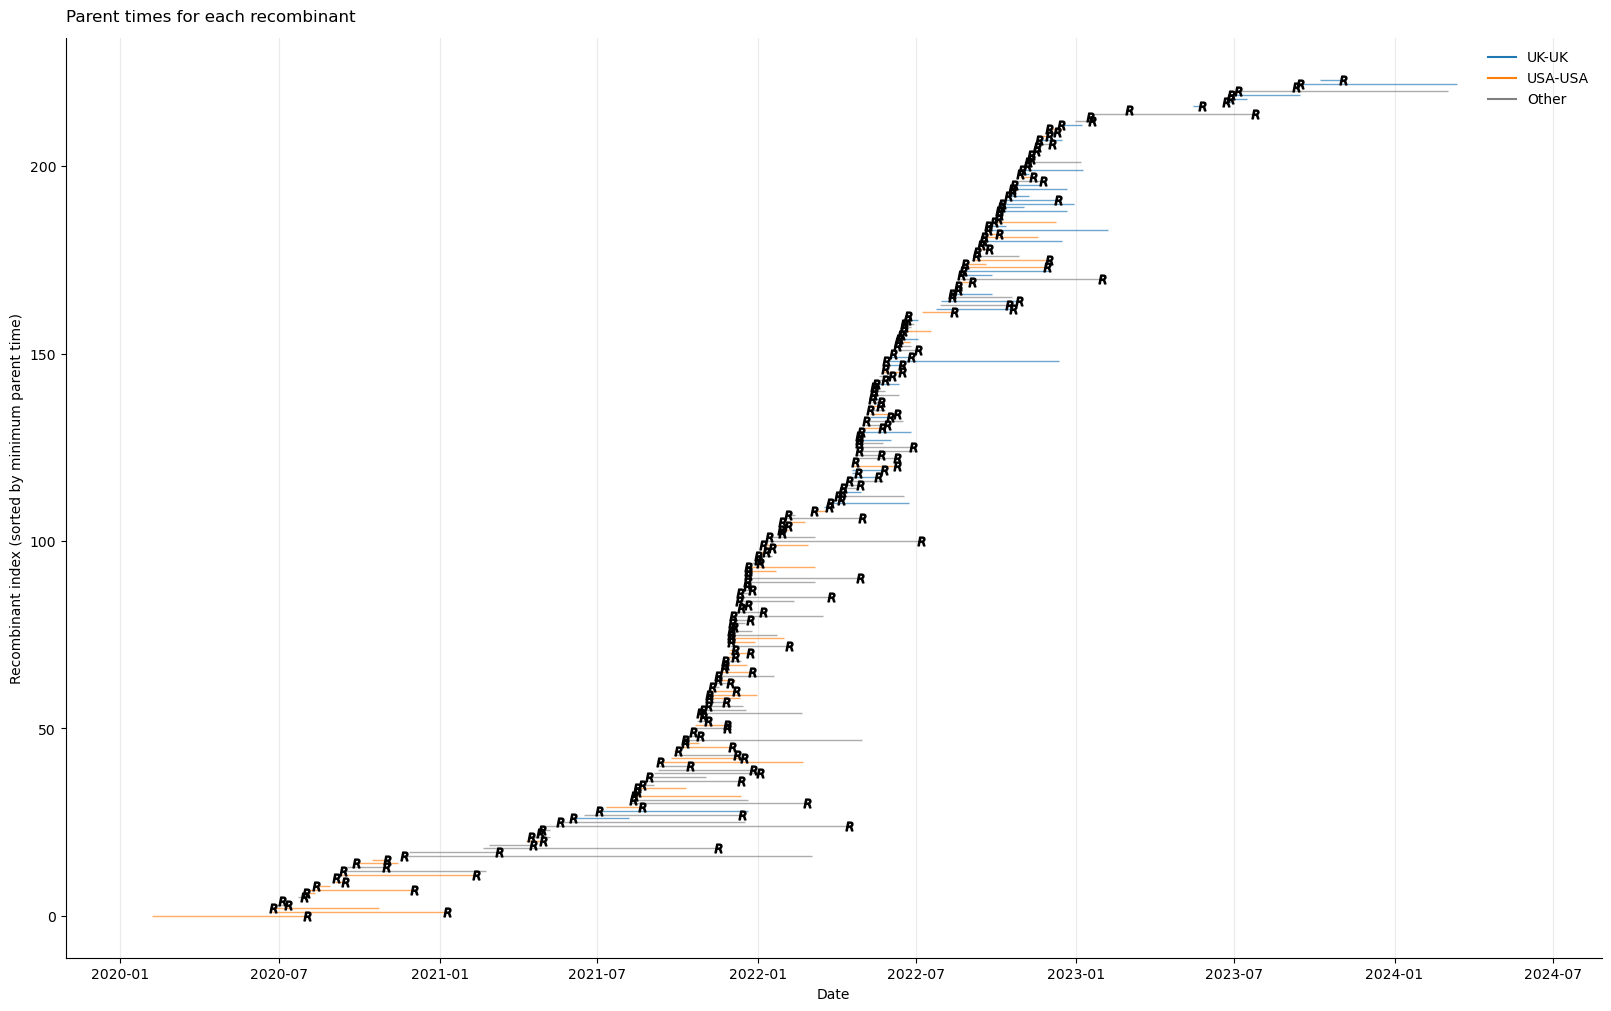

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# Interpret parent times as days from 2020-01-01.
parent_columns = ["left_parent_time", "right_parent_time"]
parent_segments = parents_df[parent_columns + ["left_parent_country", "right_parent_country"]].copy()
parent_segments["min_parent_time"] = parent_segments[parent_columns].min(axis=1)
parent_segments = parent_segments.sort_values("min_parent_time", kind="stable").reset_index(drop=True)
parent_segments["recombinant_index"] = np.arange(len(parent_segments))
origin = pd.Timestamp("2020-01-01")
parent_segments["left_parent_date"] = origin + pd.to_timedelta(parent_segments["left_parent_time"], unit="D")
parent_segments["right_parent_date"] = origin + pd.to_timedelta(parent_segments["right_parent_time"], unit="D")

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)

left_dates = mdates.date2num(parent_segments["left_parent_date"].to_numpy())
right_dates = mdates.date2num(parent_segments["right_parent_date"].to_numpy())
ranks = parent_segments["recombinant_index"]

both_uk = (parent_segments["left_parent_country"].eq("United Kingdom") &
           parent_segments["right_parent_country"].eq("United Kingdom"))
both_usa = (parent_segments["left_parent_country"].eq("USA") &
            parent_segments["right_parent_country"].eq("USA"))
segment_colors = np.select(
    [both_uk.to_numpy(dtype=bool), both_usa.to_numpy(dtype=bool)],
    ["tab:blue", "tab:orange"], default="grey"
)
ax.hlines(ranks, np.minimum(left_dates, right_dates), np.maximum(left_dates, right_dates),
          color=segment_colors, linewidth=1, alpha=0.65)

ax.scatter(right_dates, ranks, marker="$R$", s=40, color="black", zorder=3)

# Use exactly the same date ticks, labels, and limits as the daily sample plot.
ax.set_xticks(daily_sample_xticks, labels=daily_sample_xticklabels)
ax.set_xlim(daily_sample_xlim)
ax.set_xlabel("Date")
ax.set_ylabel("Recombinant index (sorted by minimum parent time)")
ax.set_title("Parent times for each recombinant", loc="left", pad=12)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[
    Line2D([0], [0], color="tab:blue", label="UK-UK"),
    Line2D([0], [0], color="tab:orange", label="USA-USA"),
    Line2D([0], [0], color="grey", label="Other"),
], frameon=False)

plt.show()